<a href="https://colab.research.google.com/github/Mal-Lem/prediction-prix-voitures/blob/main/mini_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse et Modélisation des Prix de Véhicules
Créer un modèle pour prédire le prix d’un véhicule à partir de caractéristiques techniques et visuelles, avec un dataset sale, non structuré et plein de chaînes de caractères mal formatées.

🔗 Dataset :
👉 https://www.kaggle.com/datasets/CooperUnion/cardataset

## 1. Compréhension et audit du dataset
- Charger les données
- Identifier les types de variables (numériques, catégorielles, chaînes)
- Lister les incohérences et valeurs manquantes
- Questions : colonnes utiles, corrélations potentielles, doublons/rédundances



In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Charger le dataset
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [225]:
df_copy = df.copy()

In [226]:
df.shape

(11914, 16)

In [227]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [229]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [230]:
df.drop(['Number of Doors','Market Category'], axis=1, inplace=True)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,Compact,Convertible,28,18,3916,34500


In [231]:
df.duplicated().sum()

np.int64(721)

In [232]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [233]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Vehicle Size,0
Vehicle Style,0


In [234]:
df = df.dropna(subset=['Engine Fuel Type'])

In [235]:
df['Engine HP'] = df['Engine HP'].fillna(
    df.groupby('Make')['Engine HP'].transform('mean'))
# si jamais il reste des nan après
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].mean())

<ipython-input-235-04c91123b6ff>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engine HP'] = df['Engine HP'].fillna(
<ipython-input-235-04c91123b6ff>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].mean())


In [236]:
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(
    df.groupby('Make')['Engine Cylinders'].transform('mean')
)

# si après ça il reste encore des NaN on remplace par la médiane globale
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

<ipython-input-236-c54364b53255>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engine Cylinders'] = df['Engine Cylinders'].fillna(
<ipython-input-236-c54364b53255>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())


In [237]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,0
Engine HP,0
Engine Cylinders,0
Transmission Type,0
Driven_Wheels,0
Vehicle Size,0
Vehicle Style,0


## 2. Nettoyage avancé
- Homogénéiser le format des prix
- Normaliser la cylindrée et la puissance
- Corriger les formats de date
- Uniformiser marques et modèles
- Questions : unités de puissance, traitement des lignes incohérentes


Exemples de nettoyage :
Prix : convertir "20,000 USD", "23k", "€19.5K" → nombre homogène

Cylindrée : "2.0L", "2000cc", "120 hp" → puissance normalisée

Dates : corriger les années absurdes (ex: fabrication après la vente)

Marques et modèles : uniformiser les noms ("VW", "Volkswagen", "volks wagen")

### Homogénéiser le format des prix

In [238]:
df['MSRP'].apply(type).value_counts()

,count
MSRP,
<class 'int'>,11190


In [239]:
df['MSRP'].sort_values().unique()

array([   2000,    2002,    2003, ..., 1500000, 1705769, 2065902])

Donc pas besoin de nettoyer cette colonne

<Axes: xlabel='MSRP', ylabel='Count'>

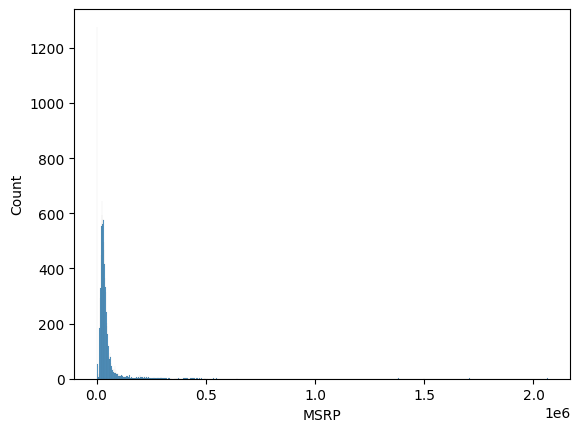

In [240]:
sns.histplot(df['MSRP'])

<Axes: xlabel='MSRP_LOG', ylabel='Count'>

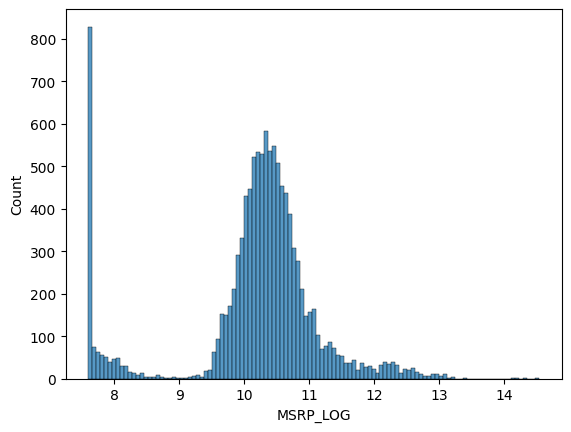

In [241]:
df['MSRP_LOG']=np.log1p(df['MSRP'])
sns.histplot(df['MSRP_LOG'])

### Normaliser la cylindrée et la puissance

In [242]:
print(df['Engine HP'].isna().sum())
print(df['Engine Cylinders'].isna().sum())

print(df[['Engine HP', 'Engine Cylinders']].describe())

0
0
          Engine HP  Engine Cylinders
count  11190.000000       11190.00000
mean     253.367973           5.66309
std      109.868921           1.79591
min       55.000000           0.00000
25%      172.000000           4.00000
50%      240.000000           6.00000
75%      303.000000           6.00000
max     1001.000000          16.00000


Engine HP :

  * La moyenne est de 253.37 avec un écart-type de 109.85.

  * Les valeurs varient de 55 à 1001, ce qui semble raisonnable, mais on va vérifier si les puissances élevées sont valides ou s’il y a des erreurs de données.

Engine Cylinders :

  * La moyenne est de 5.66, ce qui semble cohérent.

  * Le nombre de cylindres varie de 0 à 16. Le 0 cylindre est étrange et doit probablement être corrigé (peut-être des valeurs manquantes ou incorrectes).

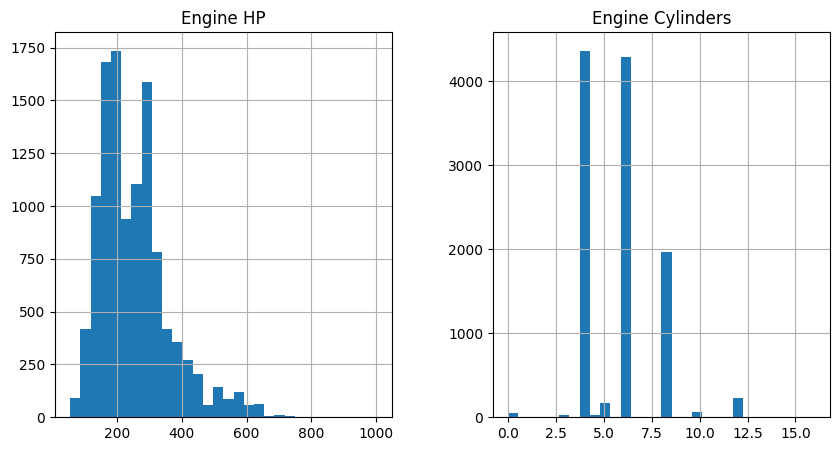

In [243]:
import matplotlib.pyplot as plt

df[['Engine HP', 'Engine Cylinders']].hist(bins=30, figsize=(10, 5))
plt.show()

In [244]:
df['Engine Cylinders'] = df['Engine Cylinders'].replace(0, df['Engine Cylinders'].median())

In [245]:
import numpy as np
df['Engine Cylinders'] = np.log1p(df['Engine Cylinders'])

In [246]:
df['Engine Cylinders'] = df['Engine Cylinders'].apply(lambda x: 8 if x > 8 else x)

In [247]:
df['Engine HP'] = df['Engine HP'].apply(lambda x: df['Engine HP'].median() if x > 500 else x)

**Normalisation :**

In [248]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Engine HP', 'Engine Cylinders']] = scaler.fit_transform(df[['Engine HP', 'Engine Cylinders']])

In [249]:
df[['Engine HP', 'Engine Cylinders']].describe()

,Engine HP,Engine Cylinders
count,11190.000000,11190.000000
mean,0.413068,0.334287
std,0.190523,0.169257
min,0.000000,0.000000
25%,0.262921,0.154220
50%,0.415730,0.386764
75%,0.532584,0.386764
max,1.000000,1.000000


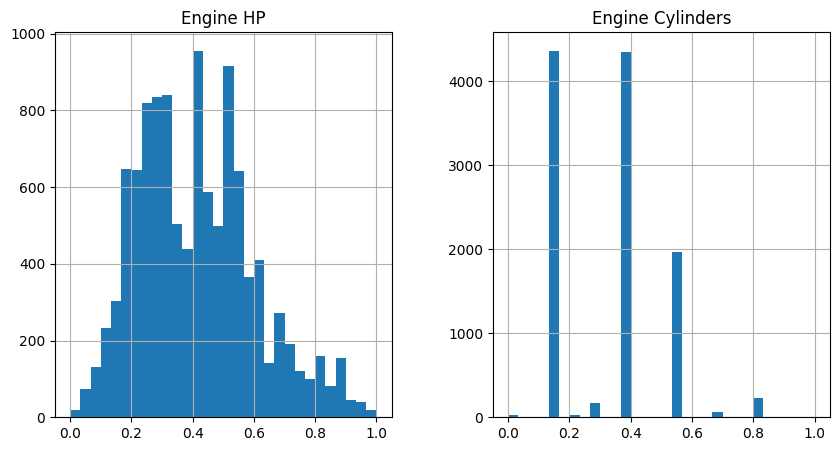

In [250]:
import matplotlib.pyplot as plt

df[['Engine HP', 'Engine Cylinders']].hist(bins=30, figsize=(10, 5))
plt.show()

### Corriger les formats de date

In [251]:
df['Year'].sort_values().unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017])

In [252]:
from datetime import datetime

current_year = datetime.now().year
df = df[(df['Year'] >= 1950) & (df['Year'] <= current_year)]

### Uniformiser marques et modèles

In [253]:
df['Make'].sort_values().unique()

array(['Acura', 'Alfa Romeo', 'Aston Martin', 'Audi', 'BMW', 'Bentley',
       'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge',
       'FIAT', 'Ferrari', 'Ford', 'GMC', 'Genesis', 'HUMMER', 'Honda',
       'Hyundai', 'Infiniti', 'Kia', 'Lamborghini', 'Land Rover', 'Lexus',
       'Lincoln', 'Lotus', 'Maserati', 'Maybach', 'Mazda', 'McLaren',
       'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Oldsmobile', 'Plymouth',
       'Pontiac', 'Porsche', 'Rolls-Royce', 'Saab', 'Scion', 'Spyker',
       'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object)

les marques sont déja unifier

In [254]:
df['Model'].value_counts()

,count
Model,
Silverado 1500,156
Tundra,129
F-150,126
Sierra 1500,90
Frontier,76
...,...
Omni,1
Corniche,1
V90,1


In [255]:
df['Model'].sort_values().unique()

array(['1 Series', '1 Series M', '100', '124 Spider', '190-Class', '2',
       '2 Series', '200', '200SX', '240', '240SX', '3', '3 Series',
       '3 Series Gran Turismo', '300', '300-Class', '3000GT', '300M',
       '300ZX', '323', '350-Class', '350Z', '360', '370Z', '4 Series',
       '4 Series Gran Coupe', '400-Class', '420-Class', '456M',
       '458 Italia', '4C', '4Runner', '5', '5 Series',
       '5 Series Gran Turismo', '500', '500-Class', '500L', '500X',
       '500e', '550', '560-Class', '57', '570S', '575M', '599', '6',
       '6 Series', '6 Series Gran Coupe', '600-Class', '6000',
       '612 Scaglietti', '62', '626', '650S Coupe', '650S Spider',
       '7 Series', '718 Cayman', '740', '760', '780', '8 Series', '80',
       '850', '86', '9-2X', '9-3', '9-3 Griffin', '9-4X', '9-5', '9-7X',
       '90', '900', '9000', '911', '928', '929', '940', '944', '960',
       '968', 'A3', 'A4', 'A4 allroad', 'A5', 'A6', 'A7', 'A8',
       'ALPINA B6 Gran Coupe', 'ALPINA B7', 'AMG GT', 

## 3. Feature Engineering (création de variables)
- Calcul de l'âge du véhicule
- Catégorisation du segment (compact, SUV, etc.)
- Encodage des variables catégorielles
- Questions : relation âge/prix, influence du segment


Exemples :
Age du véhicule = année actuelle - année de fabrication

Segment du véhicule (ex: compact, SUV, utilitaire) à partir du modèle

Encodeur ordinal ou one-hot pour les catégories (carburant, boîte auto/manuelle, etc.)

In [256]:
# Création de nouvelles variables
df['age'] = current_year - df['Year']

In [257]:
df['age'].sort_values().unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35])

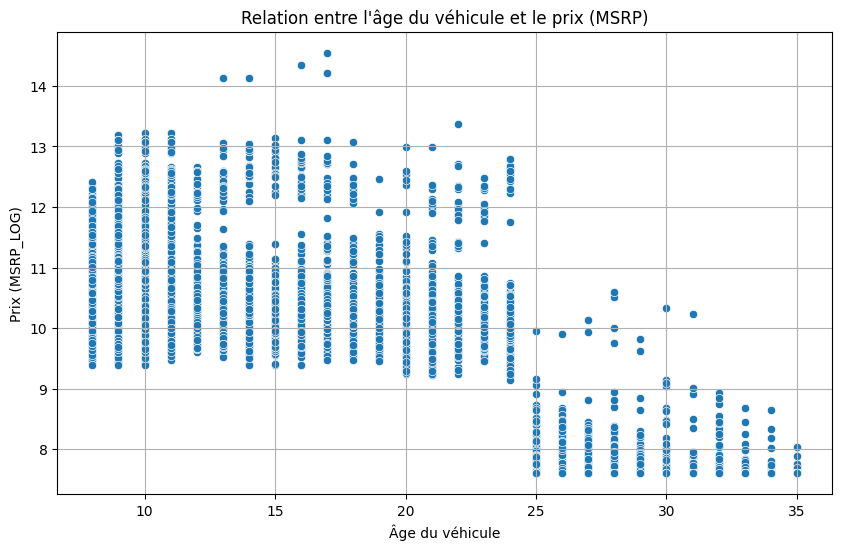

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='MSRP_LOG')
plt.title('Relation entre l\'âge du véhicule et le prix (MSRP)')
plt.xlabel('Âge du véhicule')
plt.ylabel('Prix (MSRP_LOG)')
plt.grid(True)
plt.show()

### Catégorisation du segment (compact, SUV, etc.)

In [259]:
def segment_from_model(model):
    if 'X5' in model or 'Q7' in model or 'Cherokee' in model or 'CR-V' in model or 'RAV4' in model:
        return 'SUV'

    elif 'Kangoo' in model or 'Partner' in model or 'Transit' in model or 'Ducato' in model:
        return 'Utilitaire'

    elif 'Fiesta' in model or 'Corolla' in model or 'Golf' in model or 'Focus' in model or '208' in model:
        return 'Compact'

    elif 'Accord' in model or 'Camry' in model or 'Sonata' in model or 'Passat' in model:
        return 'Berline'

    elif 'Coupé' in model or 'Mustang' in model or 'Civic' in model or 'A5' in model:
        return 'Coupé'

    elif 'Espace' in model or 'Grand' in model or 'Touran' in model or 'S-Max' in model:
        return 'Monospace'

    elif '911' in model or 'M3' in model or 'GTI' in model or 'S5' in model:
        return 'Sport'

    elif 'Kona' in model or 'Captur' in model or 'Tucson' in model:
        return 'SUV Compact'

    elif 'Z4' in model or 'S-Class' in model:
        return 'Coupé/Sport Luxe'

    elif 'Civic Type R' in model or 'GTI' in model:
        return 'Compact Sport'


    elif 'Land Cruiser' in model or 'Range Rover' in model:
        return 'SUV Haut de gamme'

    elif 'Tesla' in model or 'Leaf' in model or 'e-Golf' in model or 'Model S' in model or 'Model 3' in model or 'Model X' in model:
        return 'Électrique'
    elif 'Ranger' in model or 'Hilux' in model or 'Colorado' in model:
        return 'Pick-up'
    elif 'S-Max' in model or 'Grand Scenic' in model:
        return 'Monospace Familial'

    else:
        return 'Autre'

df['Segment'] = df['Model'].apply(segment_from_model)

In [260]:
df['Segment'].value_counts()

,count
Segment,
Autre,9992
Berline,202
Compact,196
SUV,133
Sport,123
Coupé,120
Pick-up,91
SUV Haut de gamme,86
Utilitaire,73


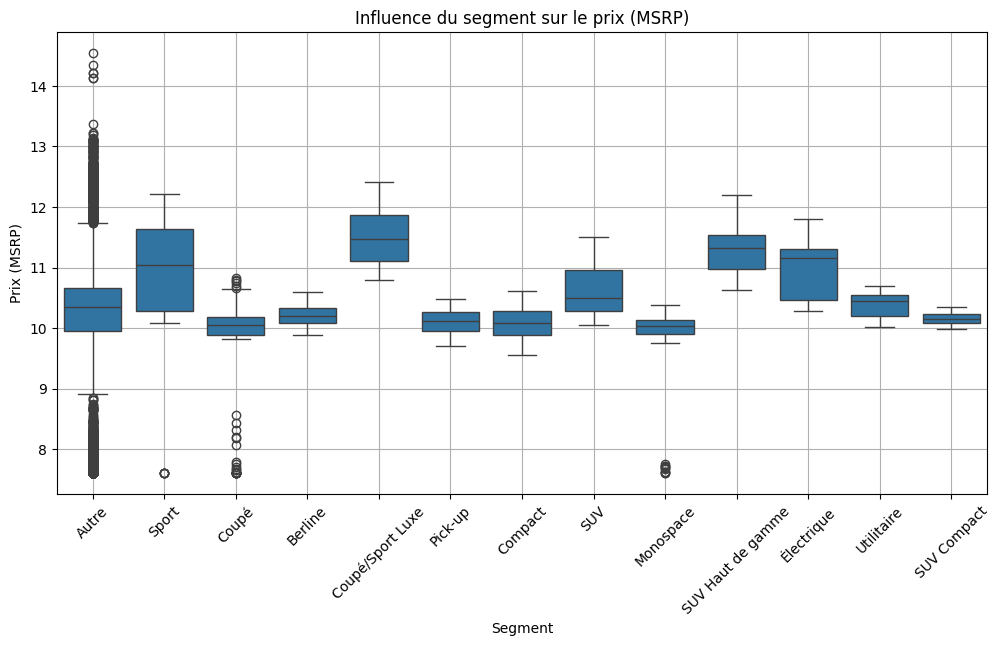

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Segment', y='MSRP_LOG')
plt.xticks(rotation=45)
plt.title('Influence du segment sur le prix (MSRP)')
plt.xlabel('Segment')
plt.ylabel('Prix (MSRP)')
plt.grid(True)
plt.show()

### Encoder les variables catégorielles

y a deux type de codage soit :
 *   Variables avec une relation d’ordre avec Label Encoding ordonné
 *   Variables sans relation d’ordre avec One-Hot Encoding

In [262]:
df['Vehicle Size'].sort_values().unique()

array(['Compact', 'Large', 'Midsize'], dtype=object)

In [263]:
from sklearn.preprocessing import OrdinalEncoder

ordre = [['Compact', 'Midsize', 'Large']]

ord_enc = OrdinalEncoder(categories=ordre)

df[['Vehicle Size']] = ord_enc.fit_transform(df[['Vehicle Size']])


In [264]:
cat_features = ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
                     'Driven_Wheels', 'Vehicle Style']
df_encod = pd.get_dummies(df, columns = cat_features)
df_encod.replace([True, False], [1, 0], inplace=True)
non_numeric_cols = df_encod.select_dtypes(exclude=[np.number]).columns
print("Colonnes non numériques :", non_numeric_cols.tolist())

<ipython-input-264-6f4aea079385>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encod.replace([True, False], [1, 0], inplace=True)


Colonnes non numériques : ['Segment']


## 4. Analyse exploratoire (EDA)
- Corrélations entre variables numériques
- Distribution du prix par segment et type de carburant
- Identification des outliers sur le prix et le kilométrage
- Analyse de la distribution des variables (histogrammes, boxplots)
- Analyse des interactions entre variables (scatter matrix)

**Questions à se poser** :
- Quelles variables numériques sont les plus corrélées avec le prix ?
- Le prix suit-il une relation linéaire ou log-linéaire avec l'âge, le kilométrage et la puissance ?
- Y a-t-il des effets de seuil ou de segments (par exemple SUV vs citadine) sur la distribution des prix ?
- Comment le kilométrage impacte-t-il le prix selon l'âge du véhicule ?
- Y a-t-il des relations non linéaires entre la puissance moteur et le prix ?
- La localisation géographique ou la date d'inscription influence-t-elle significativement le prix ?
- Quels attributs catégoriels (carburant, transmission, couleur, nombre de portes) ont un impact sur le prix ?
- Y a-t-il des valeurs aberrantes dans d'autres variables (kilométrage, âge) qui pourraient fausser les analyses ?
- Les variables formant des paires montrent-elles des interactions (par exemple âge vs puissance) ?
- Faut-il transformer certaines variables (log, racine carrée) pour linéariser leur relation avec le prix ?

<Axes: >

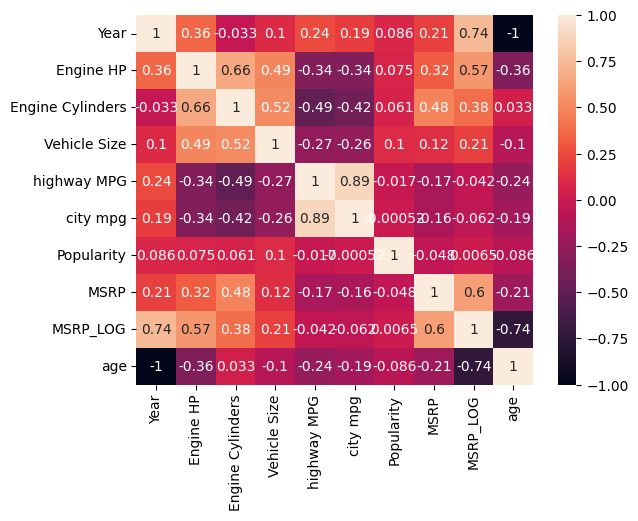

In [265]:
# Visualisations
import matplotlib.pyplot as plt
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(),annot=True)

y a : Year, Engine hp, Engine Cylinders, Popularity qui sont plus correler avec prix

In [266]:
df.drop(['MSRP'], axis=1, inplace=True)

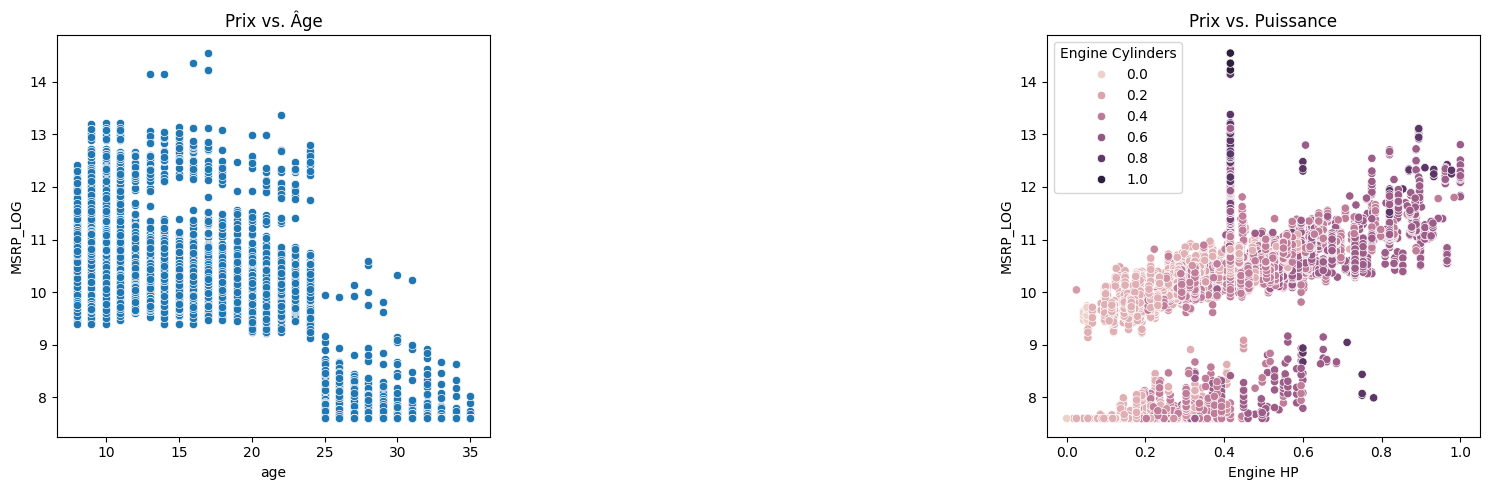

,MSRP_LOG,age,Engine HP
MSRP_LOG,1.000000,-0.737609,0.571272
age,-0.737609,1.000000,-0.357944
Engine HP,0.571272,-0.357944,1.000000


In [267]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='age', y='MSRP_LOG')
plt.title('Prix vs. Âge')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Engine HP', y='MSRP_LOG',hue='Engine Cylinders')
plt.title('Prix vs. Puissance')

plt.tight_layout()
plt.show()

correlation_matrix = df[['MSRP_LOG', 'age', 'Engine HP']].corr()
correlation_matrix

In [268]:
from scipy.stats import f_oneway

groups = [group['MSRP_LOG'].values for name, group in df.groupby('Segment')]

f_stat, p_val = f_oneway(*groups)

print(f"Statistique F : {f_stat:.2f}")
print(f"Valeur p : {p_val:.4f}")

if p_val < 0.05:
    print("→ Il y a une différence significative de prix entre les segments.")
else:
    print("→ Aucune différence significative détectée entre les segments.")


Statistique F : 27.63
Valeur p : 0.0000
→ Il y a une différence significative de prix entre les segments.


In [269]:
categorical_attributes = ['Engine Fuel Type', 'Transmission Type']

for attribute in categorical_attributes:
    groups = [group['MSRP_LOG'].values for name, group in df.groupby(attribute)]
    f_stat, p_val = f_oneway(*groups)
    print(f"Analyse de l'impact de '{attribute}' sur le prix:")
    print(f"Statistique F : {f_stat:.2f}")
    print(f"Valeur p : {p_val:.4f}")
    if p_val < 0.05:
        print("→ Il y a une différence significative de prix selon le type de", attribute)
    else:
        print("→ Aucune différence significative détectée selon le type de", attribute)
    print("-" * 20)


Analyse de l'impact de 'Engine Fuel Type' sur le prix:
Statistique F : 542.84
Valeur p : 0.0000
→ Il y a une différence significative de prix selon le type de Engine Fuel Type
--------------------
Analyse de l'impact de 'Transmission Type' sur le prix:
Statistique F : 476.89
Valeur p : 0.0000
→ Il y a une différence significative de prix selon le type de Transmission Type
--------------------


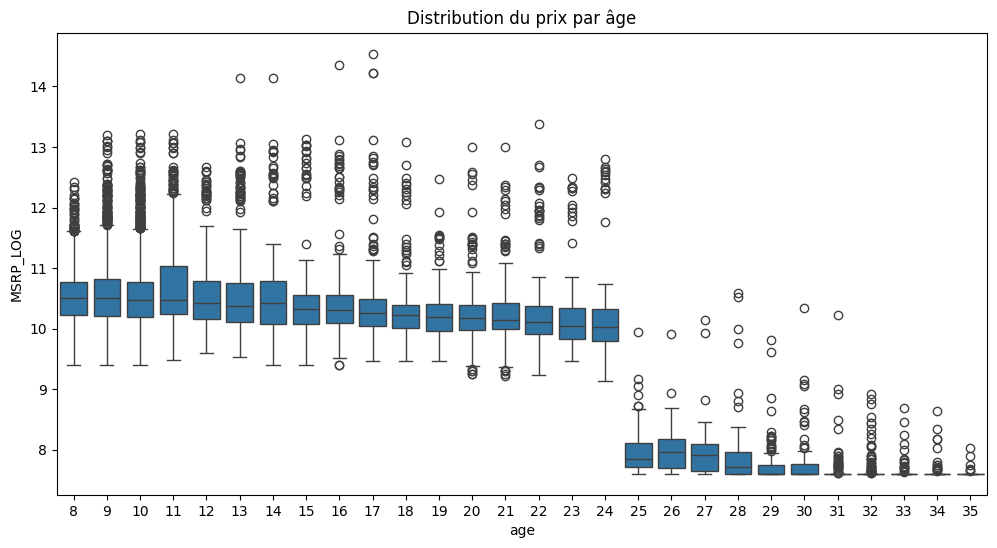

In [270]:
#analyse des outliers et des interactions entre variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='age', y='MSRP_LOG')
plt.title('Distribution du prix par âge')
plt.show()

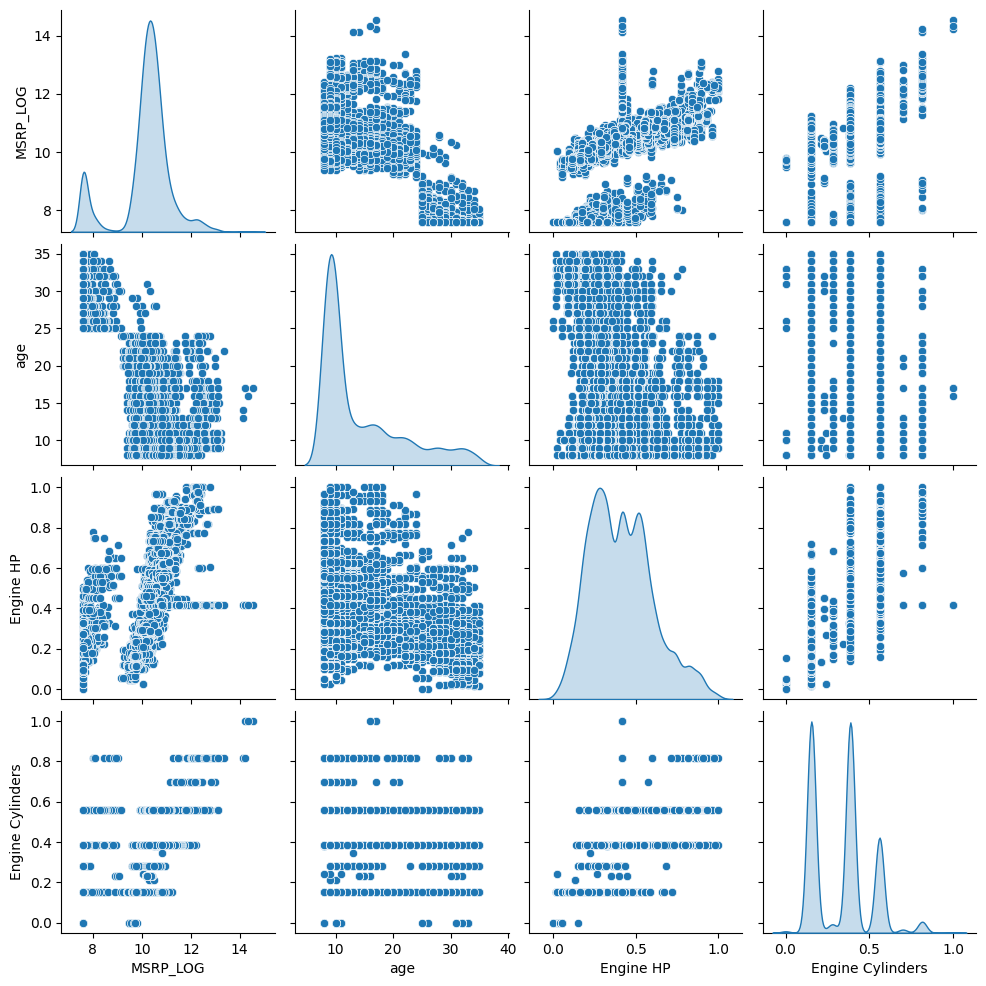

In [271]:
# analyse des interactions
sns.pairplot(df[['MSRP_LOG', 'age', 'Engine HP', 'Engine Cylinders']], diag_kind='kde')
plt.show()

MSRP_LOG est plutôt corrélé positivement avec Engine HP

MSRP_LOG diminue avec l’age, ce qui est logique

## 5. Modélisation (sans scikit-learn)
- Régression linéaire avec NumPy / statsmodels
- Évaluation performance sur validation
- Questions : variables importantes, sur-/sous-apprentissage

In [272]:
df_encod.drop(['Segment','age'], axis=1, inplace=True)

In [273]:
# Modèle de régression
import statsmodels.api as sm

X = df_encod.drop('MSRP_LOG', axis=1)
y = df_encod['MSRP_LOG']

X = sm.add_constant(X)

In [274]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()

                            OLS Regression Results                            
Dep. Variable:               MSRP_LOG   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     444.5
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        05:32:21   Log-Likelihood:                 4549.3
No. Observations:                8952   AIC:                            -7211.
Df Residuals:                    8008   BIC:                            -508.5
Df Model:                         943                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

* R-squared = 0.981 → le modèle explique 98.1% de la variance du logarithme du prix (MSRP_LOG), ce qui est excellent.

* Adj. R-squared = 0.979 → Ajusté pour le nombre de variables. Toujours très élevé, donc peu de risque de sur-ajustement par excès de variables inutiles.

* F-statistic = 444.5 avec p-value = 0.00 → Le modèle est globalement significatif (très forte relation entre les variables explicatives et la cible).

In [275]:
y_pred = model.predict(X_test)

In [276]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")


RMSE : 0.19
R² : 0.97


* R² de 0.97 sur validation est très bon : il explique 97 % de la variance des prix (en logarithme) même sur des données qu’il n’a jamais vues.

* RMSE de 0.19 est faible (dans le contexte du log du prix), donc les prédictions sont proches des vraies valeurs.

In [277]:
model.params

,0
const,-34.132567
Year,0.032730
Engine HP,0.310896
Engine Cylinders,0.081765
Vehicle Size,-0.013456
...,...
Vehicle Style_Passenger Minivan,-2.425330
Vehicle Style_Passenger Van,-2.221757
Vehicle Style_Regular Cab Pickup,-2.056151
Vehicle Style_Sedan,-2.222019


## 6. Analyse des erreurs et des résidus
- Distribution des erreurs par segment
- Résidus vs prix réel
- Détection d'outliers non captés


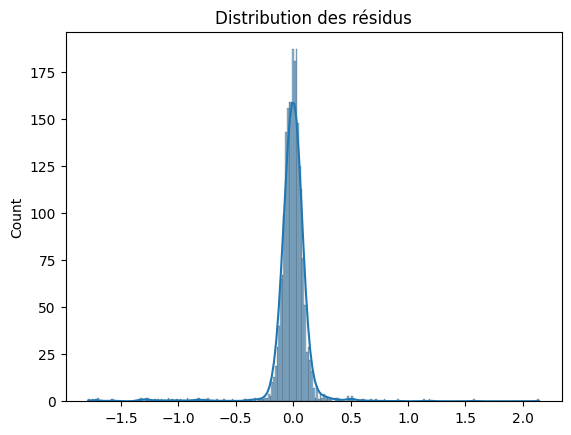

In [279]:
# Analyse des résidus
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Distribution des résidus")
plt.show()

*  Cela signifie que le modèle prédit très bien les valeurs : les erreurs sont faibles et bien réparties.

*  C’est cohérent avec le RMSE de 0.19 et R² de 0.97, qui sont d'excellentes performances.

*  Une telle forme (en cloche étroite) suggère que les erreurs suivent une distribution normale, ce qui est une bonne hypothèse pour la régression linéaire.

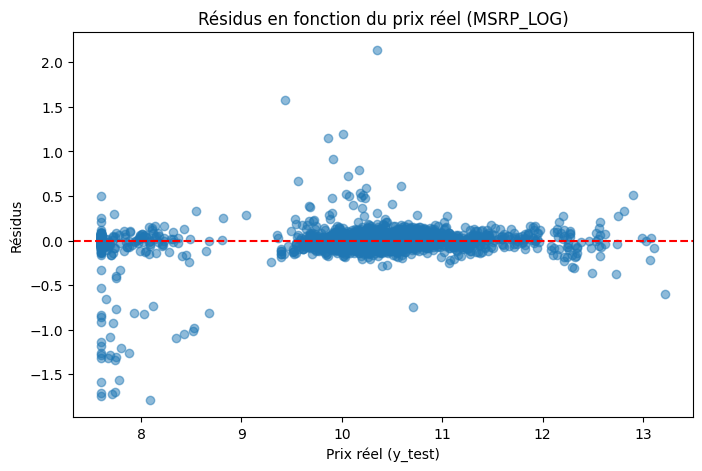

In [280]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_test - y_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Résidus en fonction du prix réel (MSRP_LOG)")
plt.xlabel("Prix réel (y_test)")
plt.ylabel("Résidus")
plt.show()

In [281]:
df_outliers = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred,
    'residuals': y_test - y_pred,
    'abs_error': abs(y_test - y_pred)
})


outliers = df_outliers.sort_values('abs_error', ascending=False).head(10)
print(outliers)

         y_test    y_pred  residuals  abs_error
2349  10.351565  8.209813   2.141753   2.141753
3881   8.088869  9.873447  -1.784578   1.784578
2425   7.601402  9.349824  -1.748422   1.748422
5950   7.711549  9.433845  -1.722296   1.722296
2426   7.601402  9.308330  -1.706928   1.706928
5952   7.736744  9.434398  -1.697654   1.697654
4221   7.601402  9.186635  -1.585233   1.585233
6800   9.434763  7.860290   1.574473   1.574473
6806   7.775696  9.339636  -1.563940   1.563940
5781   7.735870  9.080418  -1.344548   1.344548


## 7. Synthèse des résultats
- Importance des variables
- Exemples de bonnes/mauvaises prédictions
- Limites et pistes d'amélioration


Puisque on a utilisés statsmodels.OLS, l’importance des variables peut être évaluée à travers :

  * Les coefficients (model.params)
  * Les p-values (model.pvalues)

In [285]:
df_resultat = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred,
})

df_resultat["residuals"] = df_resultat["y_test"] - df_resultat["y_pred"]
df_resultat["abs_error"] = df_resultat["residuals"].abs()


In [286]:
# mauvaises prédictions
worst_preds = df_resultat.sort_values("abs_error", ascending=False).head(5)

# bonnes prédictions
best_preds = df_resultat.sort_values("abs_error").head(5)

print("❌ Mauvaises prédictions :\n", worst_preds)
print("\n✅ Bonnes prédictions :\n", best_preds)

❌ Mauvaises prédictions :
          y_test    y_pred  residuals  abs_error
2349  10.351565  8.209813   2.141753   2.141753
3881   8.088869  9.873447  -1.784578   1.784578
2425   7.601402  9.349824  -1.748422   1.748422
5950   7.711549  9.433845  -1.722296   1.722296
2426   7.601402  9.308330  -1.706928   1.706928

✅ Bonnes prédictions :
           y_test     y_pred     residuals     abs_error
7226    7.601402   7.601402 -1.511218e-10  1.511218e-10
11376   7.601402   7.601402 -1.533600e-10  1.533600e-10
10830  10.215228  10.215308 -7.970646e-05  7.970646e-05
6615   11.446796  11.446678  1.184717e-04  1.184717e-04
1492   10.756540  10.756670 -1.298219e-04  1.298219e-04


❌ Limites :

  * Le modèle est linéaire, donc il ne capture pas bien les relations non linéaires.

  * Il peut surinterpréter des variables non pertinentes si pas bien nettoyées.

  * Certaines catégories (marques rares, options moteurs spécifiques) sont sous-représentées.

🚀 Pistes d'amélioration

  * 🔄 Utiliser une transformation non linéaire (e.g., interaction terms, polynômes).

  * 🔍 Réduire la dimension (PCA ou sélection de features pour éviter le sur-apprentissage avec trop de colonnes).

  * 🧹 Améliorer le prétraitement : groupement de marques, binarisation mieux pensée, outliers filtrés.

  * 🤖 Passer à des modèles plus robustes : Random Forests, Gradient Boosting si tu pouvais utiliser scikit-learn ensuite.